DEEP LEARNING / NLP SENTIMENT CLASSIFIER

Dataset created successfully.
Dataset shape: (98, 2)

Class distribution:
label
1    49
0    49
Name: count, dtype: int64

Sample data:
                           text  label
0           I love this product      1
1  This is an excellent product      1
2       The movie was fantastic      1
3   I really enjoyed this movie      1
4        The food was delicious      1

Text preprocessing completed.

Dataset split:
Training samples   : 68
Validation samples : 15
Testing samples    : 15

TF-IDF vectorization completed.
Training TF-IDF shape   : (68, 217)
Validation TF-IDF shape : (15, 217)
Testing TF-IDF shape    : (15, 217)

MODEL ARCHITECTURE
SentimentClassifier(
  (network): Sequential(
    (0): Linear(in_features=217, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_feature

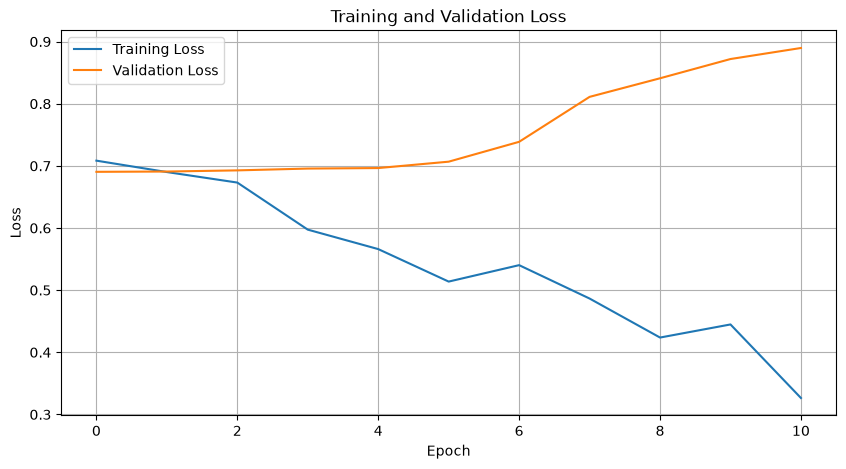

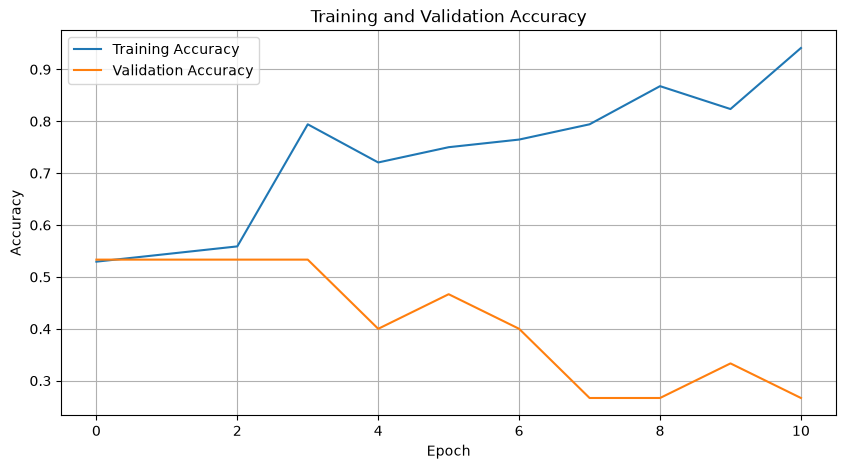


TEST RESULTS
Test Accuracy: 46.67%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         8
    Positive       0.47      1.00      0.64         7

    accuracy                           0.47        15
   macro avg       0.23      0.50      0.32        15
weighted avg       0.22      0.47      0.30        15



C:\Users\thila\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thila\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thila\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

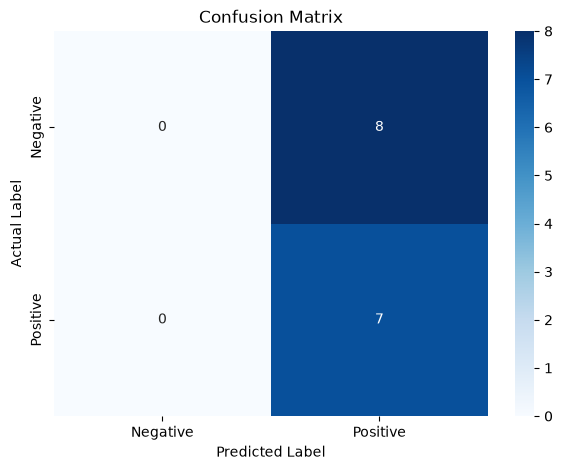


UNSEEN SAMPLE PREDICTIONS

Text: I really love this amazing product
Predicted Sentiment: Positive
Classification Confidence: 54.94%

Text: This product is very bad and disappointing
Predicted Sentiment: Positive
Classification Confidence: 55.02%

Text: The movie was excellent and enjoyable
Predicted Sentiment: Positive
Classification Confidence: 54.85%

Text: I hate this terrible experience
Predicted Sentiment: Positive
Classification Confidence: 54.70%

Text: The service was wonderful
Predicted Sentiment: Positive
Classification Confidence: 55.01%

Text: The quality of this product is horrible
Predicted Sentiment: Positive
Classification Confidence: 55.03%

Text: I am extremely happy with this purchase
Predicted Sentiment: Positive
Classification Confidence: 54.69%

Text: I would never recommend this product
Predicted Sentiment: Positive
Classification Confidence: 55.15%

PROJECT COMPLETED SUCCESSFULLY
Task             : Sentiment Analysis
Vectorization    : TF-IDF
Deep Learning    :

In [5]:
# ============================================================
# DEEP LEARNING / NLP TEXT CLASSIFIER
# SENTIMENT ANALYSIS USING TF-IDF + PYTORCH
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ------------------------------------------------------------
# 2. SET RANDOM SEED
# ------------------------------------------------------------

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("=" * 60)
print("DEEP LEARNING / NLP SENTIMENT CLASSIFIER")
print("=" * 60)


# ------------------------------------------------------------
# 3. CREATE DATASET
# ------------------------------------------------------------

positive_sentences = [
    "I love this product",
    "This is an excellent product",
    "The movie was fantastic",
    "I really enjoyed this movie",
    "The food was delicious",
    "The service was excellent",
    "I am very happy with this purchase",
    "This product is amazing",
    "The experience was wonderful",
    "I highly recommend this product",
    "The quality is outstanding",
    "This was a great experience",
    "I absolutely loved it",
    "The customer service was amazing",
    "The product works perfectly",
    "I am satisfied with my purchase",
    "This movie is very entertaining",
    "The food tasted great",
    "Everything was perfect",
    "I had a wonderful experience",
    "This is the best product",
    "I am extremely pleased",
    "The service was very good",
    "The quality is excellent",
    "I would definitely recommend this",
    "This product exceeded my expectations",
    "The movie was enjoyable",
    "I liked the product very much",
    "The experience was pleasant",
    "This purchase was worth the money",
    "I am happy with the result",
    "The product looks beautiful",
    "The food was wonderful",
    "The staff were friendly",
    "This was an amazing experience",
    "I am impressed with the quality",
    "The product is reliable",
    "I enjoyed every moment",
    "This service is excellent",
    "The movie was really good",
    "I would buy this again",
    "The product is worth buying",
    "I am very satisfied",
    "The experience was great",
    "The food was tasty",
    "This is a wonderful product",
    "I really like this service",
    "The result was excellent",
    "This is a fantastic experience"
]

negative_sentences = [
    "I hate this product",
    "This is a terrible product",
    "The movie was horrible",
    "I really disliked this movie",
    "The food was disgusting",
    "The service was terrible",
    "I am very unhappy with this purchase",
    "This product is awful",
    "The experience was horrible",
    "I would not recommend this product",
    "The quality is very poor",
    "This was a bad experience",
    "I absolutely hated it",
    "The customer service was terrible",
    "The product does not work",
    "I am disappointed with my purchase",
    "This movie is very boring",
    "The food tasted terrible",
    "Everything was disappointing",
    "I had a horrible experience",
    "This is the worst product",
    "I am extremely disappointed",
    "The service was very bad",
    "The quality is terrible",
    "I would never recommend this",
    "This product failed my expectations",
    "The movie was boring",
    "I disliked the product very much",
    "The experience was unpleasant",
    "This purchase was a waste of money",
    "I am unhappy with the result",
    "The product looks cheap",
    "The food was horrible",
    "The staff were rude",
    "This was a terrible experience",
    "I am disappointed with the quality",
    "The product is unreliable",
    "I did not enjoy the experience",
    "This service is terrible",
    "The movie was really bad",
    "I would never buy this again",
    "The product is not worth buying",
    "I am very dissatisfied",
    "The experience was bad",
    "The food was tasteless",
    "This is a horrible product",
    "I really dislike this service",
    "The result was disappointing",
    "This is a terrible experience"
]

texts = positive_sentences + negative_sentences

labels = (
    [1] * len(positive_sentences)
    + [0] * len(negative_sentences)
)

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

print("\nDataset created successfully.")
print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nSample data:")
print(df.head())


# ------------------------------------------------------------
# 4. TEXT PREPROCESSING
# ------------------------------------------------------------

def clean_text(text):
    text = text.lower()
    text = text.strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

print("\nText preprocessing completed.")


# ------------------------------------------------------------
# 5. TRAIN / VALIDATION / TEST SPLIT
# ------------------------------------------------------------

X = df["clean_text"].values
y = df["label"].values

# 70% training and 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split temporary data into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDataset split:")
print("Training samples   :", len(X_train))
print("Validation samples :", len(X_val))
print("Testing samples    :", len(X_test))


# ------------------------------------------------------------
# 6. TF-IDF TOKENIZATION AND VECTORIZATION
# ------------------------------------------------------------

vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2)
)

# Learn vocabulary only from training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform validation and test data
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF vectorization completed.")
print("Training TF-IDF shape   :", X_train_tfidf.shape)
print("Validation TF-IDF shape :", X_val_tfidf.shape)
print("Testing TF-IDF shape    :", X_test_tfidf.shape)


# ------------------------------------------------------------
# 7. CONVERT TO PYTORCH TENSORS
# ------------------------------------------------------------

X_train_tensor = torch.tensor(
    X_train_tfidf.toarray(),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_tfidf.toarray(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_tfidf.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)


# ------------------------------------------------------------
# 8. CREATE DATA LOADERS
# ------------------------------------------------------------

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)


# ------------------------------------------------------------
# 9. DEFINE DEEP NEURAL NETWORK
# ------------------------------------------------------------

input_size = X_train_tensor.shape[1]

class SentimentClassifier(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            # Layer 1
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),

            # Layer 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.20),

            # Output layer
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)


model = SentimentClassifier(input_size)

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(model)


# ------------------------------------------------------------
# 10. LOSS FUNCTION AND OPTIMIZER
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)


# ------------------------------------------------------------
# 11. TRAINING WITH EARLY STOPPING
# ------------------------------------------------------------

num_epochs = 100
patience = 10

best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print("\n" + "=" * 60)
print("TRAINING STARTED")
print("=" * 60)

for epoch in range(num_epochs):

    # -------------------------
    # TRAINING
    # -------------------------

    model.train()

    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item() * inputs.size(0)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct_train += (
            predictions == targets
        ).sum().item()

        total_train += targets.size(0)

    train_loss = total_train_loss / total_train
    train_accuracy = correct_train / total_train


    # -------------------------
    # VALIDATION
    # -------------------------

    model.eval()

    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for inputs, targets in val_loader:

            outputs = model(inputs)

            loss = criterion(outputs, targets)

            total_val_loss += loss.item() * inputs.size(0)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct_val += (
                predictions == targets
            ).sum().item()

            total_val += targets.size(0)

    val_loss = total_val_loss / total_val
    val_accuracy = correct_val / total_val


    # Store results
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # -------------------------
    # EARLY STOPPING
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        best_model_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }

    else:

        patience_counter += 1


    # Print every 5 epochs
    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch [{epoch+1:03d}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy*100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy*100:.2f}%"
        )


    # Stop if validation loss doesn't improve
    if patience_counter >= patience:

        print(
            f"\nEarly stopping triggered at epoch {epoch + 1}"
        )

        break


# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\nTraining completed successfully.")


# ------------------------------------------------------------
# 12. TRAINING LOSS GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 13. TRAINING ACCURACY GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 14. TEST MODEL
# ------------------------------------------------------------

model.eval()

all_predictions = []
all_actuals = []

with torch.no_grad():

    for inputs, targets in test_loader:

        outputs = model(inputs)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.numpy()
        )

        all_actuals.extend(
            targets.numpy()
        )


# Calculate accuracy
test_accuracy = accuracy_score(
    all_actuals,
    all_predictions
)

print("\n" + "=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)


# ------------------------------------------------------------
# 15. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        all_actuals,
        all_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)


# ------------------------------------------------------------
# 16. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    all_actuals,
    all_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()


# ------------------------------------------------------------
# 17. SENTIMENT PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_sentiment(text):

    # Clean text
    cleaned_text = clean_text(text)

    # Convert text to TF-IDF
    text_vector = vectorizer.transform(
        [cleaned_text]
    )

    # Convert to PyTorch tensor
    text_tensor = torch.tensor(
        text_vector.toarray(),
        dtype=torch.float32
    )

    # Evaluation mode
    model.eval()

    with torch.no_grad():

        output = model(text_tensor)

        # Convert output to probabilities
        probabilities = torch.softmax(
            output,
            dim=1
        )

        # Get prediction
        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_class
        ].item()

    if predicted_class == 1:

        sentiment = "Positive"

    else:

        sentiment = "Negative"

    return sentiment, confidence


# ------------------------------------------------------------
# 18. TEST UNSEEN SAMPLE INPUTS
# ------------------------------------------------------------

sample_inputs = [

    "I really love this amazing product",

    "This product is very bad and disappointing",

    "The movie was excellent and enjoyable",

    "I hate this terrible experience",

    "The service was wonderful",

    "The quality of this product is horrible",

    "I am extremely happy with this purchase",

    "I would never recommend this product"
]


print("\n" + "=" * 60)
print("UNSEEN SAMPLE PREDICTIONS")
print("=" * 60)

for text in sample_inputs:

    sentiment, confidence = predict_sentiment(text)

    print("\nText:", text)

    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        "Classification Confidence:",
        f"{confidence * 100:.2f}%"
    )


# ------------------------------------------------------------
# 19. SAVE TRAINED MODEL
# ------------------------------------------------------------

torch.save(
    model.state_dict(),
    "sentiment_classifier.pth"
)

with open(
    "tfidf_vectorizer.pkl",
    "wb"
) as file:

    pickle.dump(
        vectorizer,
        file
    )


# ------------------------------------------------------------
# 20. FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Task             : Sentiment Analysis")
print("Vectorization    : TF-IDF")
print("Deep Learning    : PyTorch")
print("Neural Network   : Multi-Layer Neural Network")
print("Dropout          : Yes")
print("Batch Norm       : Yes")
print("Early Stopping   : Yes")
print("Optimizer        : Adam")
print("Loss Function    : Cross Entropy")
print(f"Test Accuracy    : {test_accuracy * 100:.2f}%")
print("Model File       : sentiment_classifier.pth")
print("Vectorizer File  : tfidf_vectorizer.pkl")

print("\nYou can now submit the .ipynb notebook with")
print("the graphs, test results, confusion matrix,")
print("and unseen sample predictions.")